In [1]:
### 0 - Load libraries and configure project paths

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve the project root whether the notebook runs from the project root
# or from the notebook/ subfolder.
possible_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (path for path in possible_roots if (path / "data" / "raw").exists()),
    Path.cwd()
)

DATA_DIR = PROJECT_ROOT / "data" / "raw"
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Images folder:", IMAGES_DIR)


Project root: c:\Users\Warren Jones\OneDrive\Desktop\exploratory-data-analysis-business-insights
Data folder: c:\Users\Warren Jones\OneDrive\Desktop\exploratory-data-analysis-business-insights\data\raw
Images folder: c:\Users\Warren Jones\OneDrive\Desktop\exploratory-data-analysis-business-insights\images


In [2]:
### 1 - Load dataset

df = pd.read_csv(DATA_DIR / "House_Price.csv")

In [3]:
### 2 - Display

## 2a - Show First 5 Rows
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
## 2b - Show Dataset Shape
df.shape

(1460, 81)

In [6]:
## 2c - Show Missing Values
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [7]:
### 3 - Compute descriptive statistics

## 3a, b, c - Compute descriptive stats for SalePrice

df[['SalePrice','GrLivArea','LotArea']].describe()

,SalePrice,GrLivArea,LotArea
count,1460.000000,1460.000000,1460.000000
mean,180921.195890,1515.463699,10516.828082
std,79442.502883,525.480383,9981.264932
min,34900.000000,334.000000,1300.000000
25%,129975.000000,1129.500000,7553.500000
50%,163000.000000,1464.000000,9478.500000
75%,214000.000000,1776.750000,11601.500000
max,755000.000000,5642.000000,215245.000000


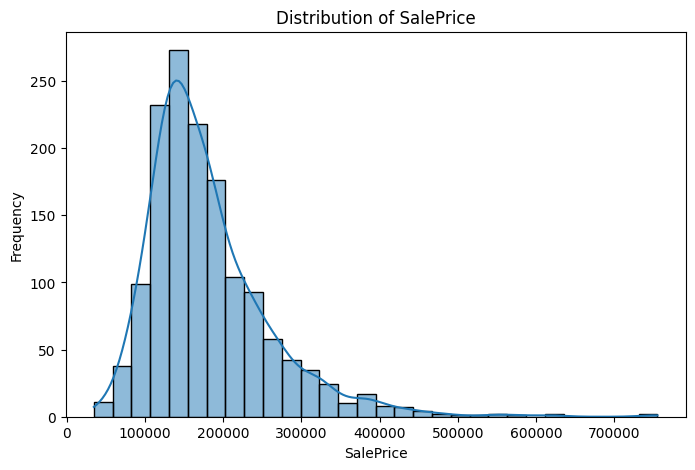

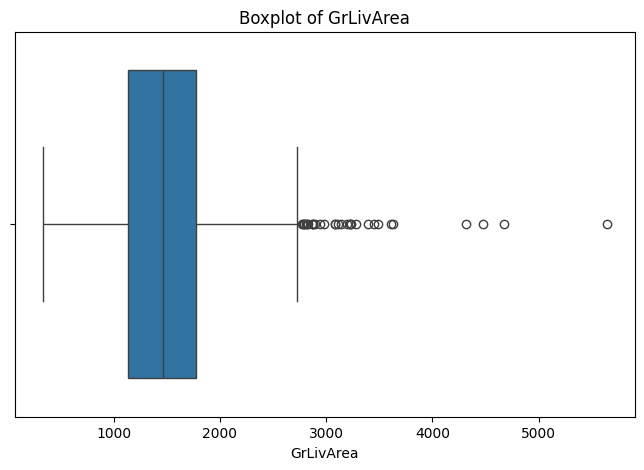

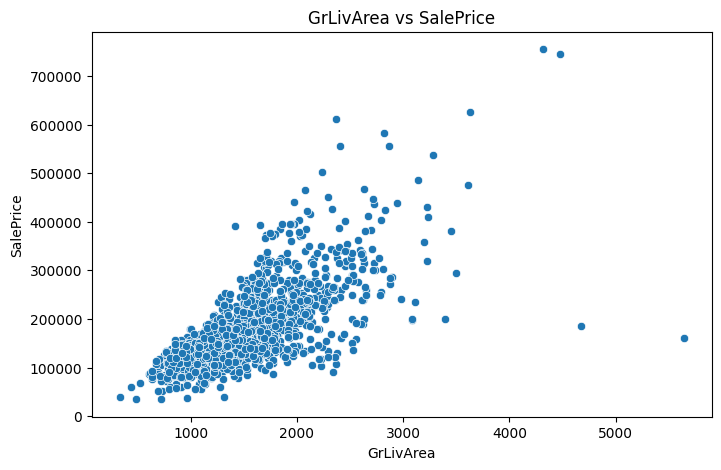

In [8]:
### 4 - Create plots

## 4a - Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.savefig(IMAGES_DIR / "housing_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4b - Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['GrLivArea'])
plt.title("Boxplot of GrLivArea")
plt.savefig(IMAGES_DIR / "housing_grlivarea_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 4c - Scatterplot
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.savefig(IMAGES_DIR / "housing_grlivarea_vs_saleprice.png", dpi=300, bbox_inches="tight")
plt.show()



###Questions
The housing prices are right-skewed, meaning more homes are priced at the lower-to-middle portion of data than the high end. There are a few outliers in price and living area observed in the data.

In terms of price, there are two homes that cost more than \$700,000 and several others that cost more than \$500,000. In terms of size, outliers include one home larger than 5,000sf and three others larger than 4,000sf.

In [9]:
### 5 - Using Interquartile Range

## 5a - Compute Q1, Q3, and IQR
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 129975.0
Q3: 214000.0
IQR: 84025.0


In [10]:
## 5b - Determine bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 3937.5
Upper Bound: 340037.5


In [11]:
## Define IQR outliers
iqr_outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]

In [12]:
## 5c - Identify houses where SalePrice lies outside the bounds
iqr_outliers[['SalePrice']].reset_index().rename(columns={'index':'House Index'})

,House Index,SalePrice
0,11,345000
1,53,385000
2,58,438780
3,112,383970
4,151,372402
...,...,...
56,1268,381000
57,1353,410000
58,1373,466500
59,1388,377500


In [13]:
## 5d - Count how many outliers are detected
print("Number of outliers detected:", iqr_outliers.shape[0])

Number of outliers detected: 61


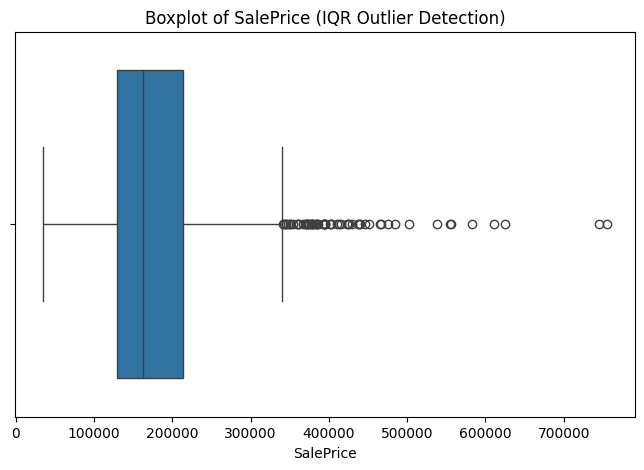

In [14]:
## 5e - Visualize using a box plot

plt.figure(figsize=(8,5))
sns.boxplot(x=df['SalePrice'])

plt.title("Boxplot of SalePrice (IQR Outlier Detection)")
plt.xlabel("SalePrice")

plt.savefig(IMAGES_DIR / "housing_saleprice_iqr_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Questions

The normal range of housing prices is from \$3,937.50 to \$340,037.50, calculated using the IQR method.

61 outliers were identified using the IQR method.



In [15]:
### 6 - Using the Z-Score method

## 6a - Compute Z-score for SalePrice
mean_price = df['SalePrice'].mean()
std_price = df['SalePrice'].std()

df['Z_Score'] = (df['SalePrice'] - mean_price) / std_price

df[['SalePrice','Z_Score']].head()

,SalePrice,Z_Score
0,208500,0.347154
1,181500,0.007286
2,223500,0.535970
3,140000,-0.515105
4,250000,0.869545


In [16]:
## 6b - Use threshold: ∣ 𝑍 ∣> 3, Identify extreme houses
df['Outlier'] = df['Z_Score'].abs() > 3

df[['SalePrice','Z_Score','Outlier']].head()


,SalePrice,Z_Score,Outlier
0,208500,0.347154,False
1,181500,0.007286,False
2,223500,0.535970,False
3,140000,-0.515105,False
4,250000,0.869545,False


In [17]:
## 6c - Create a table
z_table = df[['SalePrice','Z_Score','Outlier']].reset_index()
z_table.rename(columns={'index':'House Index'}, inplace=True)

z_table.head()

,House Index,SalePrice,Z_Score,Outlier
0,0,208500,0.347154,False
1,1,181500,0.007286,False
2,2,223500,0.535970,False
3,3,140000,-0.515105,False
4,4,250000,0.869545,False


In [18]:
### 7 - Compute statistics before removing outliers

## 7a - Mean SalePrice, Median SalePrice, Standard deviation
mean_price = df['SalePrice'].mean()
median_price = df['SalePrice'].median()
std_price = df['SalePrice'].std()

print("Mean:", round(mean_price, 2))
print("Median:", round(median_price, 2))
print("Standard Deviation:", round(std_price, 2))

## 7b - Show the range of SalePrice which covers 95% and 99.7% of the data points
range_95 = (mean_price - 2 * std_price, mean_price + 2 * std_price)
range_997 = (mean_price - 3 * std_price, mean_price + 3 * std_price)

print("95% range:", (round(range_95[0], 2), round(range_95[1], 2)))
print("99.7% range:", (round(range_997[0], 2), round(range_997[1], 2)))

Mean: 180921.2
Median: 163000.0
Standard Deviation: 79442.5
95% range: (np.float64(22036.19), np.float64(339806.2))
99.7% range: (np.float64(-57406.31), np.float64(419248.7))


In [19]:
### 8 - Remove outliers detected using IQR

df_no_outliers = df[(df['SalePrice'] >= lower_bound) & (df['SalePrice'] <= upper_bound)]

mean_new = df_no_outliers['SalePrice'].mean()
median_new = df_no_outliers['SalePrice'].median()
std_new = df_no_outliers['SalePrice'].std()

print("Mean after removing outliers:", round(mean_new, 2))
print("Median after removing outliers:", round(median_new, 2))
print("Standard deviation after removing outliers:", round(std_new, 2))

Mean after removing outliers: 170237.13
Median after removing outliers: 159500.0
Standard deviation after removing outliers: 59230.13


In [20]:
## 0 - Load dataset
df_netflix = pd.read_csv(DATA_DIR / "netflix_titles.csv")

In [21]:
## 1 - Show shape, columns, and data types, Identify categorical vs numerical columns and Count duplicates
# Shape of dataset
print("Shape:", df_netflix.shape)

# Column names
print("\nColumns:")
print(df_netflix.columns)

# Data types
print("\nData Types:")
print(df_netflix.dtypes)

# Numerical columns
numerical_cols = df_netflix.select_dtypes(include=['int64','float64']).columns
print("\nNumerical Columns:", list(numerical_cols))

# Categorical columns
categorical_cols = df_netflix.select_dtypes(include=['object']).columns
print("\nCategorical Columns:", list(categorical_cols))

# Count duplicates
duplicates = df_netflix.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)


Shape: (8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

Numerical Columns: ['release_year']

Categorical Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']

Number of duplicate rows: 0


<positron-console-cell-21>:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


In [22]:
## 2 - Calculate missing % per column, Visualize missing data. Which 3 columns have highest missing?[ ]

# Calculate missing values
missing_counts = df_netflix.isnull().sum()

# Calculate percentage
missing_percent = (missing_counts / len(df_netflix)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

# Sort from highest missing to lowest
missing_summary = missing_summary.sort_values(by="Missing %", ascending=False)

missing_summary

,Missing Count,Missing %
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
release_year,0,0.000000


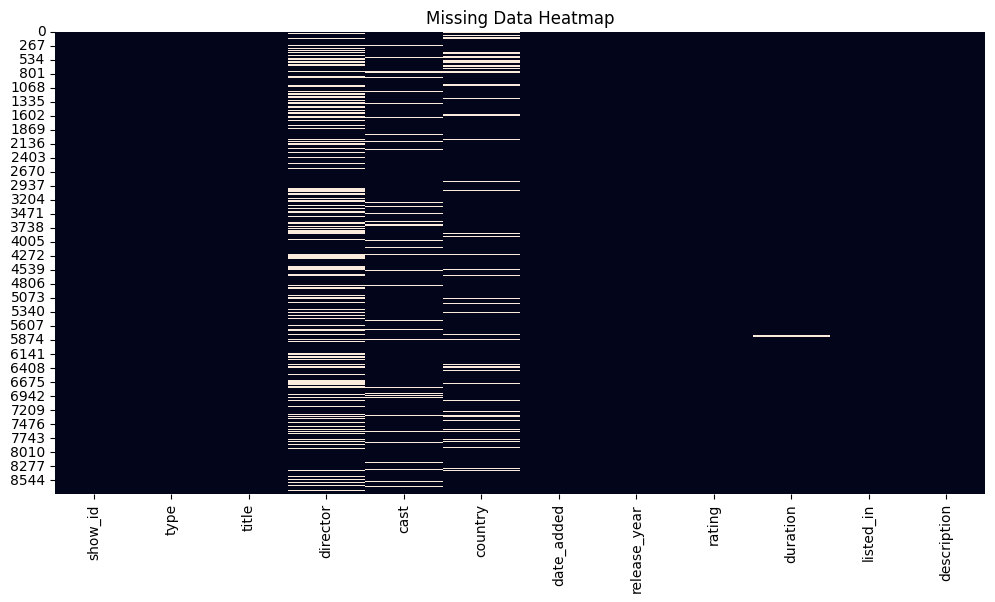

In [23]:
# Visualize missing data
plt.figure(figsize=(12,6))
sns.heatmap(df_netflix.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.savefig(IMAGES_DIR / "netflix_missing_data_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Director, country, and cast are the columns that have the highest missing by percentage.

In [24]:
## 4a-b - Convert date_added to datetime and extract
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], errors='coerce')

df_netflix['year_added'] = df_netflix['date_added'].dt.year
df_netflix['month_added'] = df_netflix['date_added'].dt.month

df_netflix[['date_added', 'year_added', 'month_added']].head()


,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [25]:
## 5a-b - Convert duration into numeric

df_netflix['duration_num'] = df_netflix['duration'].str.extract('(\d+)').astype(float)

# For movies -> minutes
df_netflix['movie_minutes'] = df_netflix.apply(
    lambda x: x['duration_num'] if x['type'] == 'Movie' else None,
    axis=1
)

# For TV Shows -> number of seasons
df_netflix['tv_seasons'] = df_netflix.apply(
    lambda x: x['duration_num'] if x['type'] == 'TV Show' else None,
    axis=1
)

df_netflix[['type', 'duration', 'duration_num', 'movie_minutes', 'tv_seasons']].head(10)

<positron-console-cell-25>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.


,type,duration,duration_num,movie_minutes,tv_seasons
0,Movie,90 min,90.0,90.0,NaN
1,TV Show,2 Seasons,2.0,NaN,2.0
2,TV Show,1 Season,1.0,NaN,1.0
3,TV Show,1 Season,1.0,NaN,1.0
4,TV Show,2 Seasons,2.0,NaN,2.0
5,TV Show,1 Season,1.0,NaN,1.0
6,Movie,91 min,91.0,91.0,NaN
7,Movie,125 min,125.0,125.0,NaN
8,TV Show,9 Seasons,9.0,NaN,9.0
9,Movie,104 min,104.0,104.0,NaN


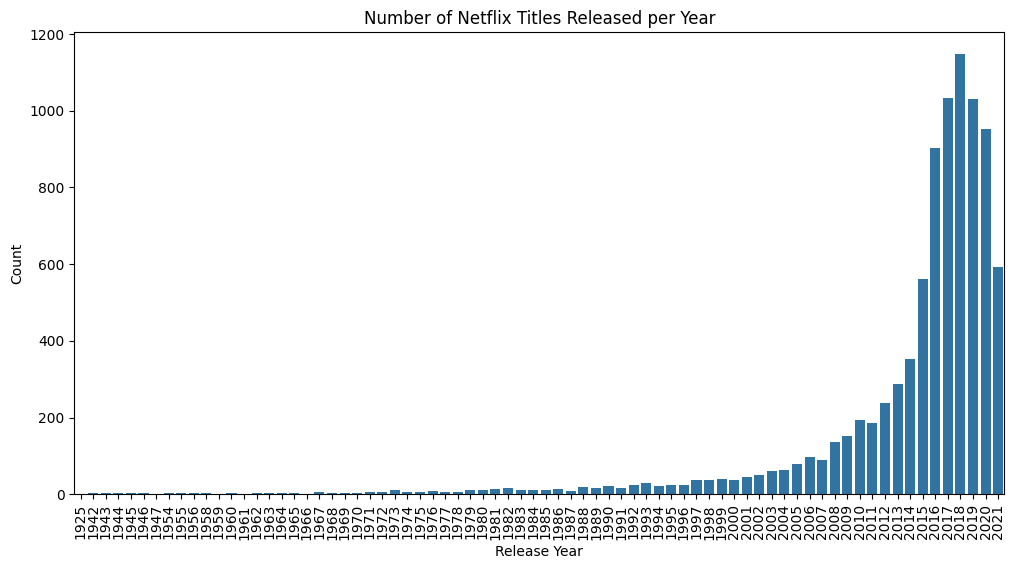

In [26]:
# 6 - Plot number of releases per year (One variable or Univariate Analysis).

plt.figure(figsize=(12,6))
sns.countplot(data=df_netflix, x='release_year', order=df_netflix['release_year'].value_counts().sort_index().index)
plt.xticks(rotation=90)
plt.title("Number of Netflix Titles Released per Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.savefig(IMAGES_DIR / "netflix_titles_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
## 6a - df_netflix['release_year'].value_counts().head(1)

2018 was the year with the most releases.

In [28]:
## 6b - Is Netflix focusing more on recent content?
df_netflix['release_year'].value_counts().sort_index().tail(10)

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

The results show that Netflix is focused more on recent content. This is evident by the sheer number of more recent content versus older titles, including its peak in 2018.

In [29]:
## 7a - Most common rating
df_netflix['rating'].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

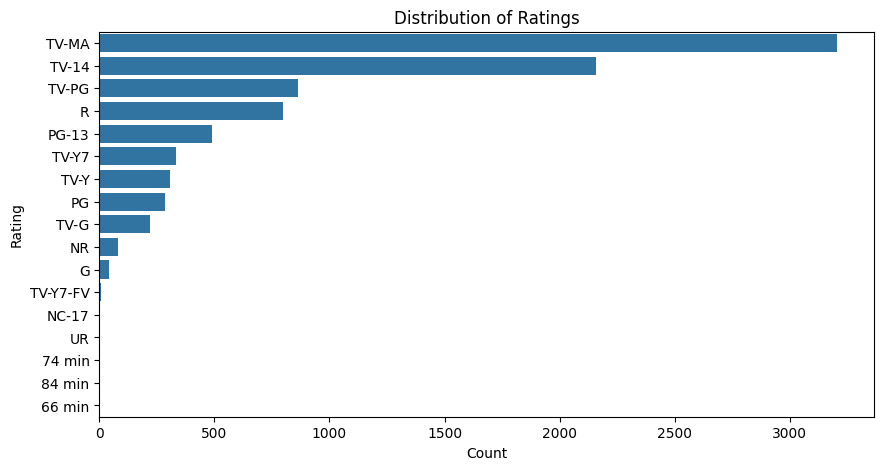

In [30]:
# 7b - Distribution of ratings
plt.figure(figsize=(10,5))
sns.countplot(data=df_netflix, y='rating', order=df_netflix['rating'].value_counts().index)
plt.title("Distribution of Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.savefig(IMAGES_DIR / "netflix_rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

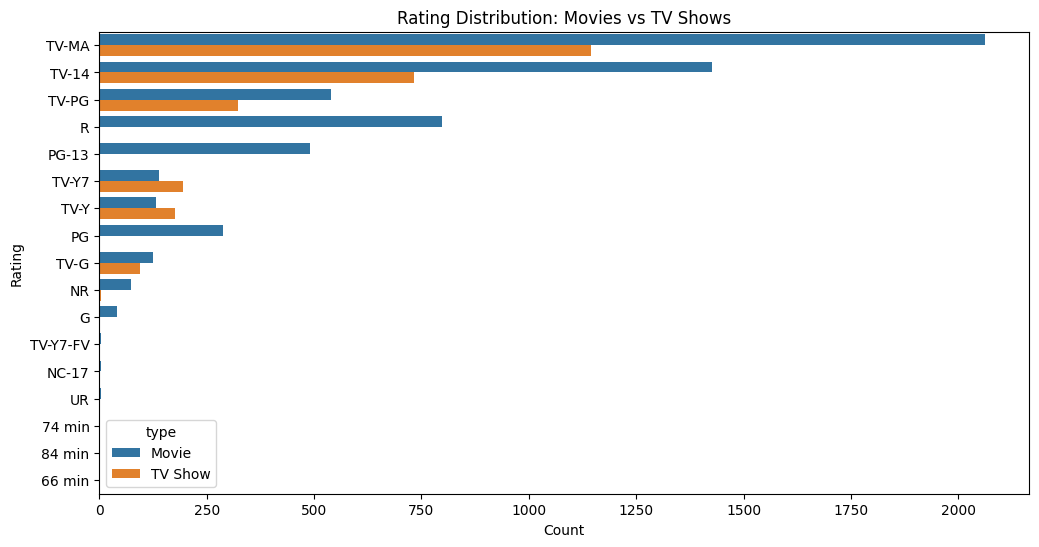

In [31]:
# 7c - Compare rating distribution for Movies vs TV Shows
plt.figure(figsize=(12,6))
sns.countplot(data=df_netflix, y='rating', hue='type', order=df_netflix['rating'].value_counts().index)
plt.title("Rating Distribution: Movies vs TV Shows")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

In [32]:
## 8 - Movies-only dataframe
movies_df = df_netflix[df_netflix['type'] == 'Movie'].copy()
movies_df[['title', 'duration', 'movie_minutes']].head()

,title,duration,movie_minutes
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0


In [33]:
# 8a - Mean, median duration
print("Mean movie duration:", round(movies_df['movie_minutes'].mean(), 2))
print("Median movie duration:", round(movies_df['movie_minutes'].median(), 2))

Mean movie duration: 99.58
Median movie duration: 98.0


In [34]:
# 8b - Outlier detection (IQR)
Q1 = movies_df['movie_minutes'].quantile(0.25)
Q3 = movies_df['movie_minutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

duration_outliers = movies_df[
    (movies_df['movie_minutes'] < lower_bound) |
    (movies_df['movie_minutes'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of movie duration outliers:", duration_outliers.shape[0])

Lower Bound: 46.5
Upper Bound: 154.5
Number of movie duration outliers: 450


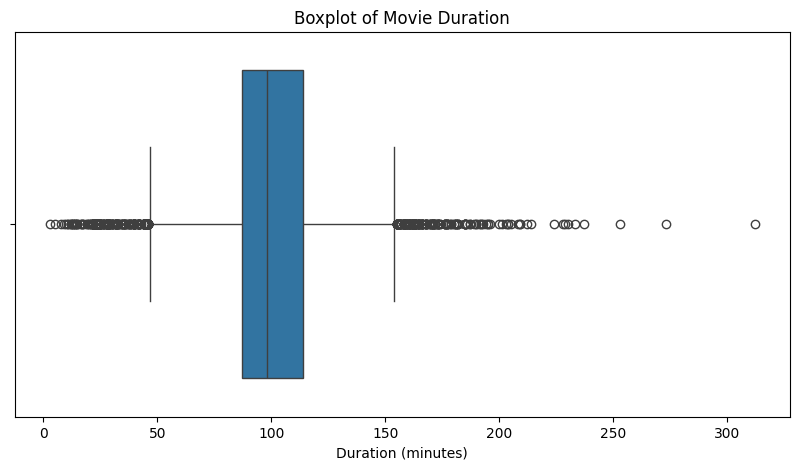

In [35]:
# Boxplot of movie duration
plt.figure(figsize=(10,5))
sns.boxplot(x=movies_df['movie_minutes'])
plt.title("Boxplot of Movie Duration")
plt.xlabel("Duration (minutes)")
plt.show()

In [36]:
# 8c - Longest 5 movies
movies_df[['title', 'movie_minutes']].sort_values(by='movie_minutes', ascending=False).head(5)

,title,movie_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0


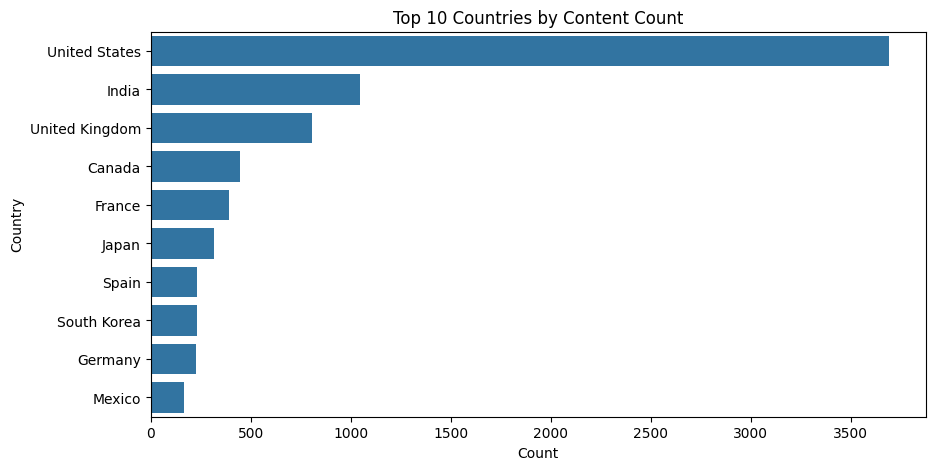

In [37]:
# 9a - Top 10 countries by content count
country_counts = df_netflix['country'].dropna().str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title("Top 10 Countries by Content Count")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

In [40]:
# 9b - Movies vs TV Shows Produced by Country

country_type = df_netflix.dropna(subset=["country", "type"]).copy()

# Split multi-country entries into lists
country_type["country"] = country_type["country"].str.split(", ")

# Create one row per country
country_type = country_type.explode("country")

# Clean country names
country_type["country"] = country_type["country"].str.strip()

# Count titles by country and content type
country_type_summary = (
    country_type
    .groupby(["country", "type"])
    .size()
    .unstack(fill_value=0)
)

# Sort by available columns
sort_cols = [col for col in ["Movie", "TV Show"] if col in country_type_summary.columns]

country_type_summary = (
    country_type_summary
    .sort_values(by=sort_cols, ascending=False)
    .head(10)
)

country_type_summary

type,Movie,TV Show
country,,
United States,2751,938
India,962,84
United Kingdom,532,272
Canada,319,126
France,303,90
Germany,182,44
Spain,171,61
Japan,119,199
China,114,48


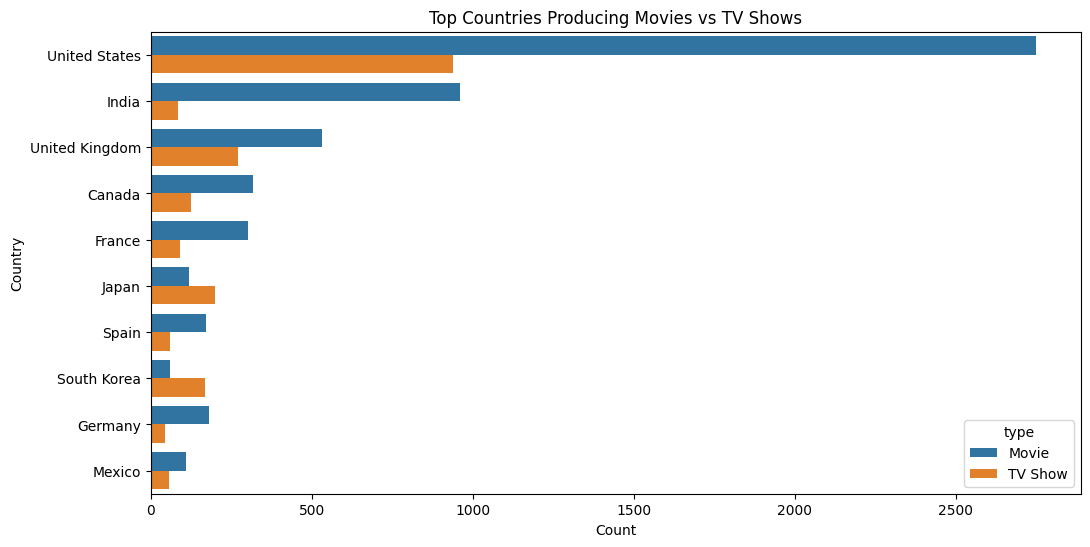

In [41]:
# Plot top countries by Movies and TV Shows
top_countries = country_type['country'].value_counts().head(10).index
top_country_type = country_type[country_type['country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.countplot(data=top_country_type, y='country', hue='type', order=top_countries)
plt.title("Top Countries Producing Movies vs TV Shows")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

The United States produces the most movies and tv shows.

In [42]:
# 10a - Split listed_in into multiple genres
genre_df = df_netflix.copy()
genre_df['listed_in'] = genre_df['listed_in'].str.split(', ')
genre_exploded = genre_df.explode('listed_in')
genre_exploded[['title', 'type', 'listed_in']].head()

,title,type,listed_in
0,Dick Johnson Is Dead,Movie,Documentaries
1,Blood & Water,TV Show,International TV Shows
1,Blood & Water,TV Show,TV Dramas
1,Blood & Water,TV Show,TV Mysteries
2,Ganglands,TV Show,Crime TV Shows


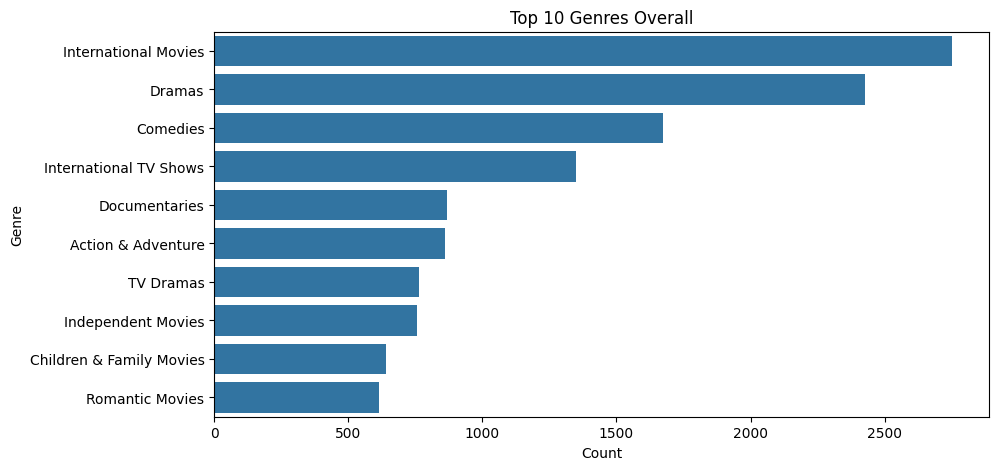

In [43]:
# 10b - Top 10 genres overall
top_genres = genre_exploded['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres Overall")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [44]:
# 10c - Top genre for Movies
movie_genres = genre_exploded[genre_exploded['type'] == 'Movie']['listed_in'].value_counts()
movie_genres.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: count, dtype: int64

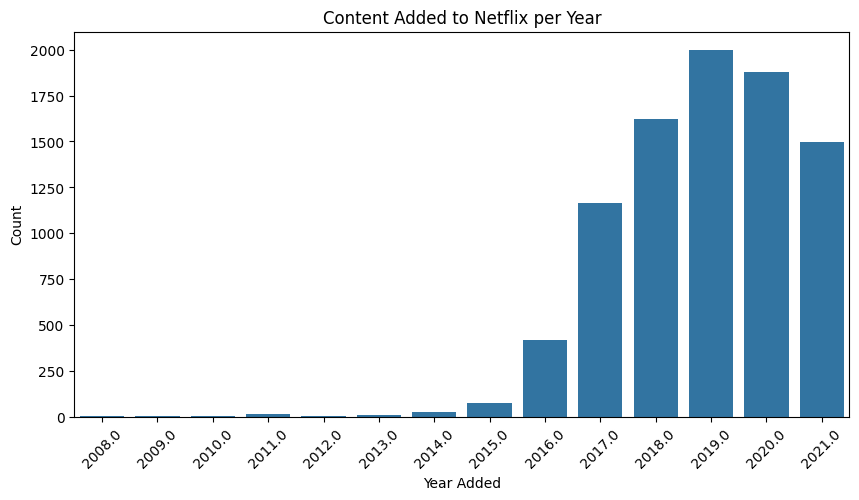

In [45]:
# 11a - Content added per year
plt.figure(figsize=(10,5))
sns.countplot(data=df_netflix, x='year_added', order=sorted(df_netflix['year_added'].dropna().unique()))
plt.xticks(rotation=45)
plt.title("Content Added to Netflix per Year")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()

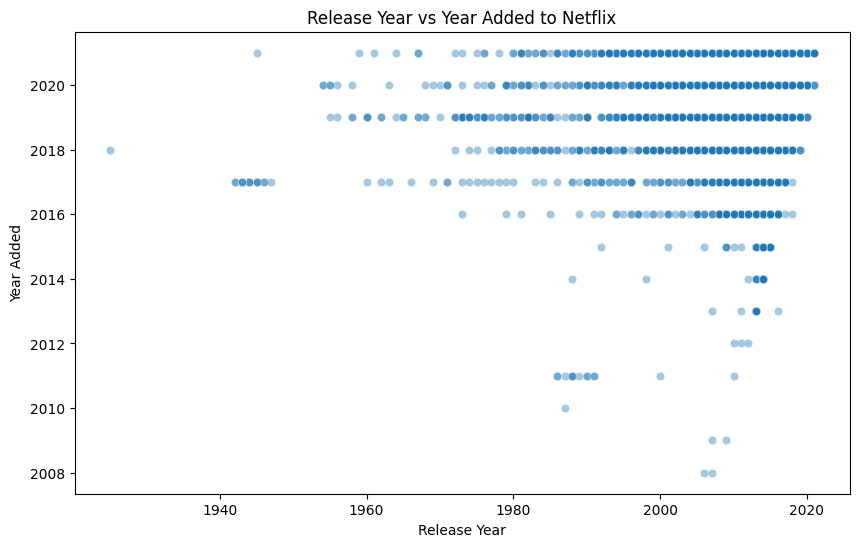

In [46]:
# 11b - Compare release year vs year added
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_netflix, x='release_year', y='year_added', alpha=0.4)
plt.title("Release Year vs Year Added to Netflix")
plt.xlabel("Release Year")
plt.ylabel("Year Added")
plt.show()

In [47]:
# 11c - Identify delay between release and Netflix addition
df_netflix['addition_delay'] = df_netflix['year_added'] - df_netflix['release_year']
df_netflix[['title', 'release_year', 'year_added', 'addition_delay']].head()

,title,release_year,year_added,addition_delay
0,Dick Johnson Is Dead,2020,2021.0,1.0
1,Blood & Water,2021,2021.0,0.0
2,Ganglands,2021,2021.0,0.0
3,Jailbirds New Orleans,2021,2021.0,0.0
4,Kota Factory,2021,2021.0,0.0


In [48]:
# Delay summary
df_netflix['addition_delay'].describe()

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: addition_delay, dtype: float64

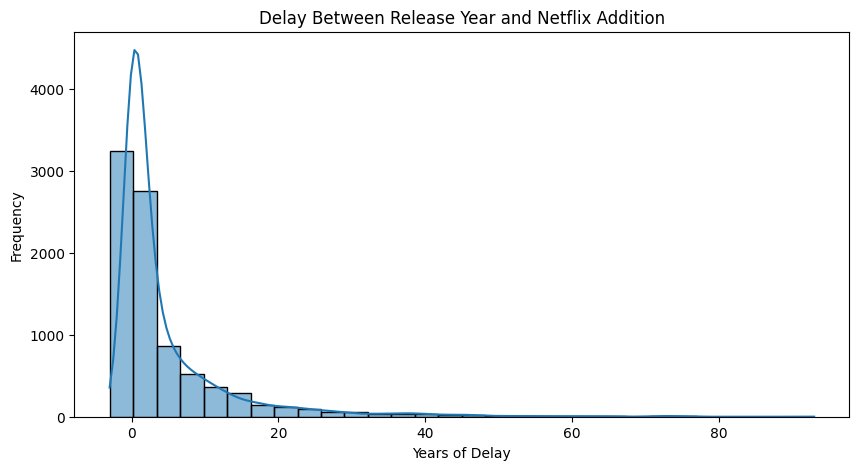

In [49]:
# Delay distribution
plt.figure(figsize=(10,5))
sns.histplot(df_netflix['addition_delay'].dropna(), bins=30, kde=True)
plt.title("Delay Between Release Year and Netflix Addition")
plt.xlabel("Years of Delay")
plt.ylabel("Frequency")
plt.show()

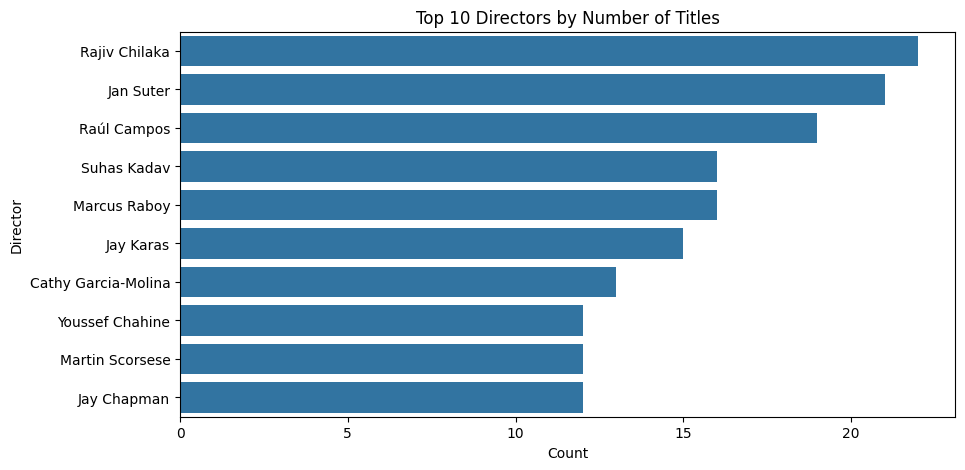

In [50]:
# 12a - Top 10 directors by number of titles
top_directors = df_netflix['director'].dropna().str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Count")
plt.ylabel("Director")
plt.show()

In [51]:
# 12b - Actor appearing most frequently
top_actors = df_netflix['cast'].dropna().str.split(', ').explode().value_counts()
top_actors.head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

Anupam Kher is the actor who appears most frequently.

In [52]:
# 12c - Director with highest average movie duration
director_duration = movies_df.dropna(subset=['director', 'movie_minutes']).copy()
director_duration['director'] = director_duration['director'].str.split(', ')
director_duration = director_duration.explode('director')

director_avg_duration = director_duration.groupby('director')['movie_minutes'].mean().sort_values(ascending=False)
director_avg_duration.head(10)

director
Houssam El-Din Mustafa    253.000000
Samir Al Asfory           237.000000
Fouad El-Mohandes         233.000000
Fouad Al Shatti           204.000000
Hussein Kamal             201.500000
David Lean                200.000000
Sergio Leone              197.500000
Bassam Kurdali            196.000000
Hassan AbdulSalam         195.000000
Ashutosh Gowariker        194.166667
Name: movie_minutes, dtype: float64

Houssam El-Din Mustafa is the director with the highest average movie duration.

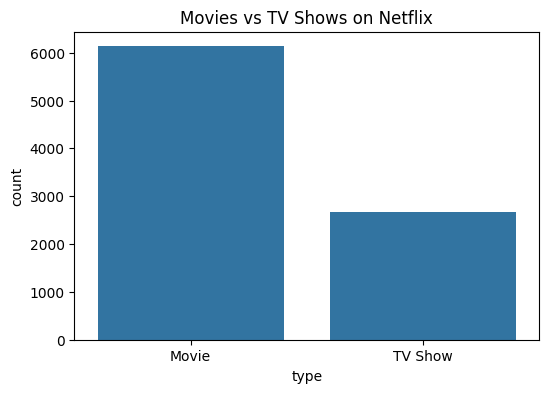

In [53]:
# 13a — Is Netflix more movie-focused or series-focused?
plt.figure(figsize=(6,4))
sns.countplot(data=df_netflix, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

Netflix is more movie-focused than series-focused.

In [54]:
# 13b — Does Netflix prefer recent releases?

df_netflix['release_year'].value_counts().sort_index().tail(10)

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

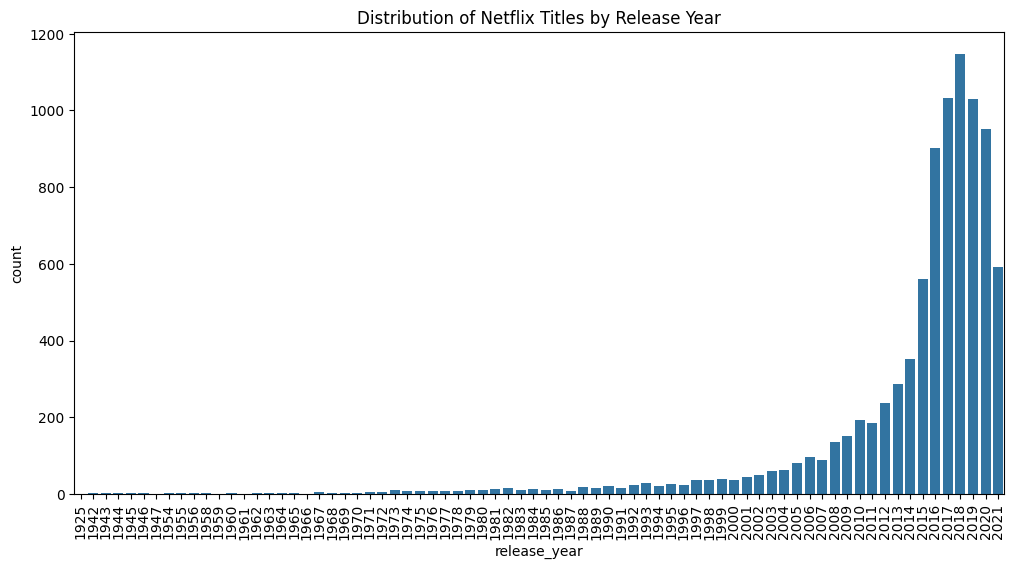

In [55]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_netflix, x='release_year')
plt.xticks(rotation=90)
plt.title("Distribution of Netflix Titles by Release Year")
plt.show()

The data shows that Netflix favors recent released based as demonstrated by the right-skewed distribution toward recent years (after early-2000s).

In [56]:
# 13c — Which rating category dominates?

df_netflix['rating'].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

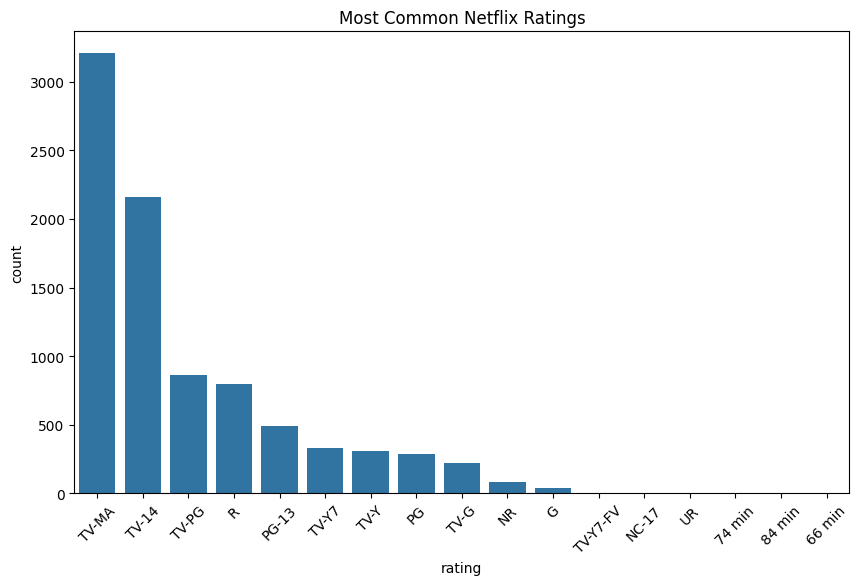

In [57]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_netflix, x='rating', order=df_netflix['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Most Common Netflix Ratings")
plt.show()

TV-MA is the dominate ratings category.

In [58]:
# Recall movies-only dataset
movies = df_netflix[df_netflix['type'] == 'Movie']

In [59]:
# 13d — Which country contributes most long-duration content?

long_movies = movies.sort_values(by='movie_minutes', ascending=False)

long_movies[['country','title','movie_minutes']].head(10)

,country,title,movie_minutes
4253,United States,Black Mirror: Bandersnatch,312.0
717,NaN,Headspace: Unwind Your Mind,273.0
2491,Egypt,The School of Mischief,253.0
2487,Egypt,No Longer kids,237.0
2484,NaN,Lock Your Girls In,233.0
2488,NaN,Raya and Sakina,230.0
166,"Italy, United States",Once Upon a Time in America,229.0
7932,India,Sangam,228.0
1019,"India, United Kingdom",Lagaan,224.0
4573,India,Jodhaa Akbar,214.0


In [60]:
movies.groupby('country')['movie_minutes'] \
.mean() \
.sort_values(ascending=False) \
.head(10)

country
United Kingdom, United States, Japan                   208.0
United States, United Kingdom, Morocco                 205.0
United States, Italy, United Kingdom, Liechtenstein    200.0
New Zealand, United States                             190.0
Romania, France, Switzerland, Germany                  186.0
France, Belgium, Spain                                 180.0
Germany, United States, Hong Kong, Singapore           172.0
India, Soviet Union                                    161.5
United Kingdom, United States, Morocco                 161.0
India, United Kingdom                                  160.0
Name: movie_minutes, dtype: float64

Long-duration content is primarily produced by multi-country productions. The United States is involved in several of these types of productions.

## Question 3 - NYC Airbnb Open Data

In [61]:
# 1a-d - Load the dataset and display: shape, column names, data types and Identify numerical and categorical
df_airbnb = pd.read_csv(DATA_DIR / "AB_NYC_2019.csv")

In [62]:
print("Shape:", df_airbnb.shape)

Shape: (48895, 16)


In [63]:
print(df_airbnb.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')


In [64]:
print(df_airbnb.dtypes)

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [65]:
numerical_cols = df_airbnb.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_airbnb.select_dtypes(include=['object']).columns

print("Numerical Variables:", list(numerical_cols))
print("Categorical Variables:", list(categorical_cols))

Numerical Variables: ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical Variables: ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


<positron-console-cell-65>:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


In [66]:
# 2 - Check missing values and report percentage
missing_summary_airbnb = pd.DataFrame({
    "Missing Count": df_airbnb.isnull().sum(),
    "Missing %": (df_airbnb.isnull().sum() / len(df_airbnb)) * 100
}).sort_values(by="Missing %", ascending=False)

missing_summary_airbnb

,Missing Count,Missing %
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


In [67]:
# 3 - Provide a summary statistics table
df_airbnb.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [68]:
# 4 - Perform processing

In [69]:
## 4a - Handle missing values
df_airbnb['name'] = df_airbnb['name'].fillna('Unknown')
df_airbnb['host_name'] = df_airbnb['host_name'].fillna('Unknown')
df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(0)

In [70]:
df_airbnb[['name', 'host_name', 'reviews_per_month']].isnull().sum()

name                 0
host_name            0
reviews_per_month    0
dtype: int64

In [71]:
## 4b - Remove extreme price outliers (justify your threshold)
Q1_price = df_airbnb['price'].quantile(0.25)
Q3_price = df_airbnb['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

In [72]:
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

print("Lower Bound:", lower_bound_price)
print("Upper Bound:", upper_bound_price)

Lower Bound: -90.0
Upper Bound: 334.0


In [73]:
df_airbnb_clean = df_airbnb[
    (df_airbnb['price'] >= lower_bound_price) &
    (df_airbnb['price'] <= upper_bound_price)
].copy()

In [74]:
print("Original shape:", df_airbnb.shape)
print("Cleaned shape:", df_airbnb_clean.shape)

Original shape: (48895, 16)
Cleaned shape: (45923, 16)


Using the IQR method, I identified the extreme values in price. While the lower bound was negative, that is not realistic for price data. The upper bound of 334 is useful to identifying extreme price outliers. Values above the upper bound were removed and treated as outliers.

In [75]:
## 4c - Convert neighbourhood_group and room_type into categorical variables
df_airbnb_clean['neighbourhood_group'] = df_airbnb_clean['neighbourhood_group'].astype('category')
df_airbnb_clean['room_type'] = df_airbnb_clean['room_type'].astype('category')

In [76]:
df_airbnb_clean[['neighbourhood_group', 'room_type']].dtypes

neighbourhood_group    category
room_type              category
dtype: object

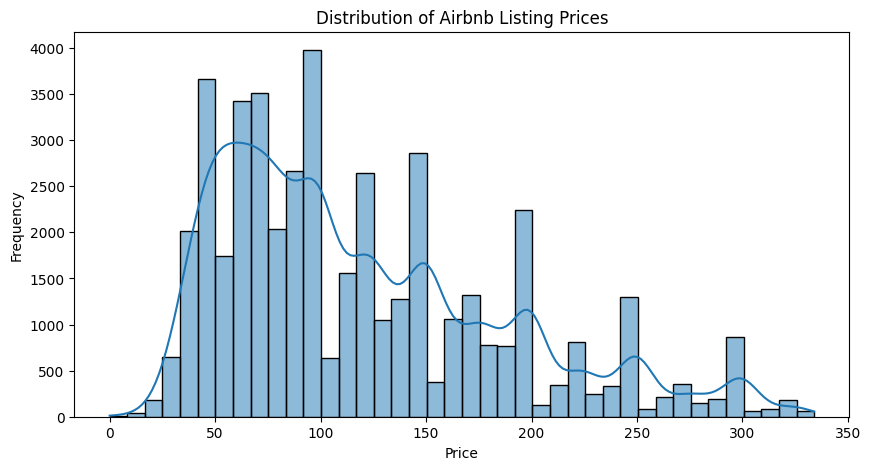

In [77]:
# 5 - Analyze the distribution

## 5a - Distribution of price
plt.figure(figsize=(10,5))
sns.histplot(df_airbnb_clean['price'], bins=40, kde=True)
plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig(IMAGES_DIR / "airbnb_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


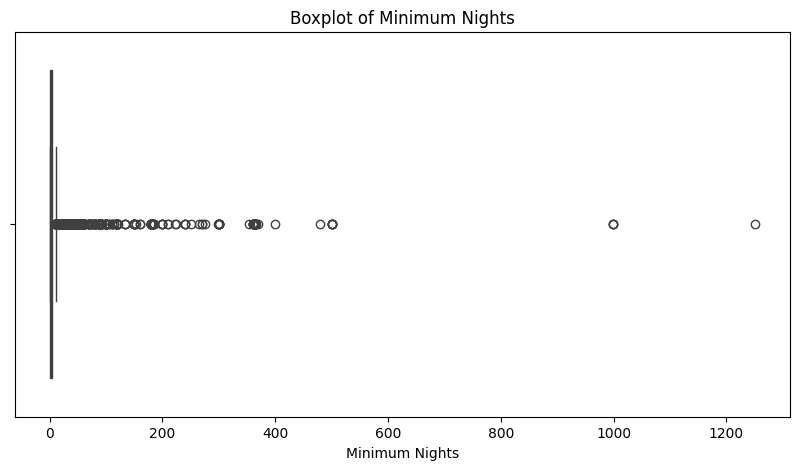

In [78]:
## 5b - Distribution of minimum_nights
plt.figure(figsize=(10,5))
sns.boxplot(x=df_airbnb_clean['minimum_nights'])
plt.title("Boxplot of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.show()

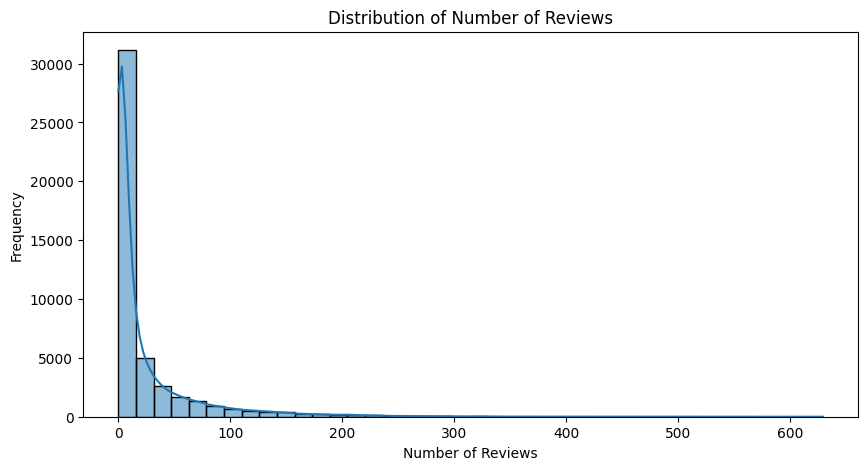

In [79]:
## 5c - Distribution of number_of_reviews
plt.figure(figsize=(10,5))
sns.histplot(df_airbnb_clean['number_of_reviews'], bins=40, kde=True)
plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

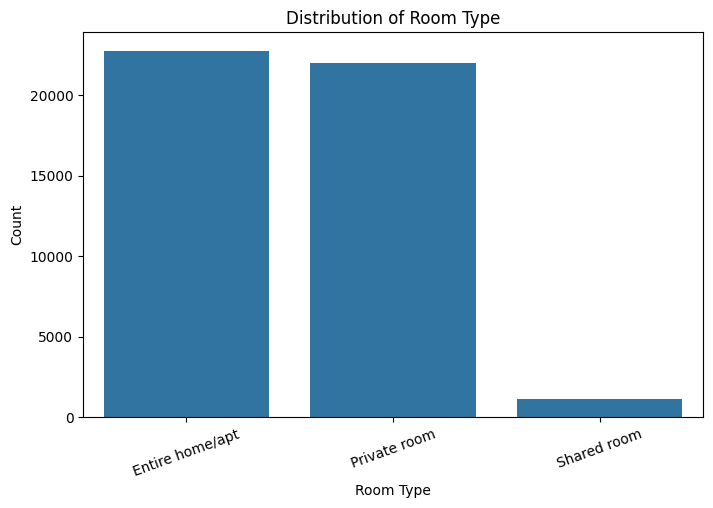

In [80]:
## 5d - Distribution of room_type
plt.figure(figsize=(8,5))
sns.countplot(data=df_airbnb_clean, x='room_type')
plt.title("Distribution of Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.savefig(IMAGES_DIR / "airbnb_room_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

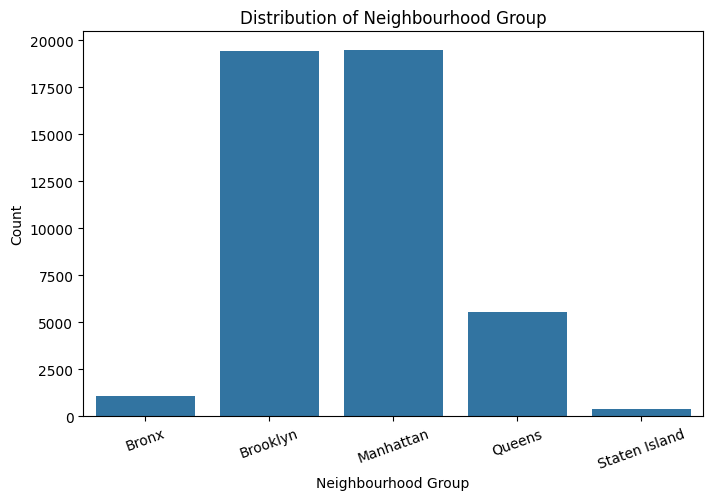

In [81]:
## 5e - Distribution of neighbourhood_group
plt.figure(figsize=(8,5))
sns.countplot(data=df_airbnb_clean, x='neighbourhood_group')
plt.title("Distribution of Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.savefig(IMAGES_DIR / "airbnb_neighborhood_group_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

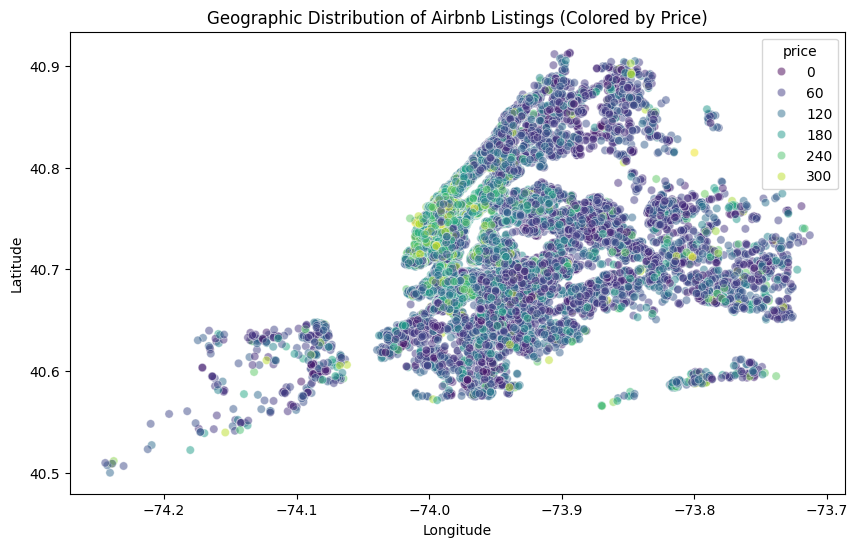

In [82]:
# 6 - Use latitude and longitude to complete spatial analysis

## 6a - Scatter plot of listings across NYC
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_airbnb_clean,
    x='longitude',
    y='latitude',
    hue='price',
    palette='viridis',
    alpha=0.5
)

plt.title("Geographic Distribution of Airbnb Listings (Colored by Price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

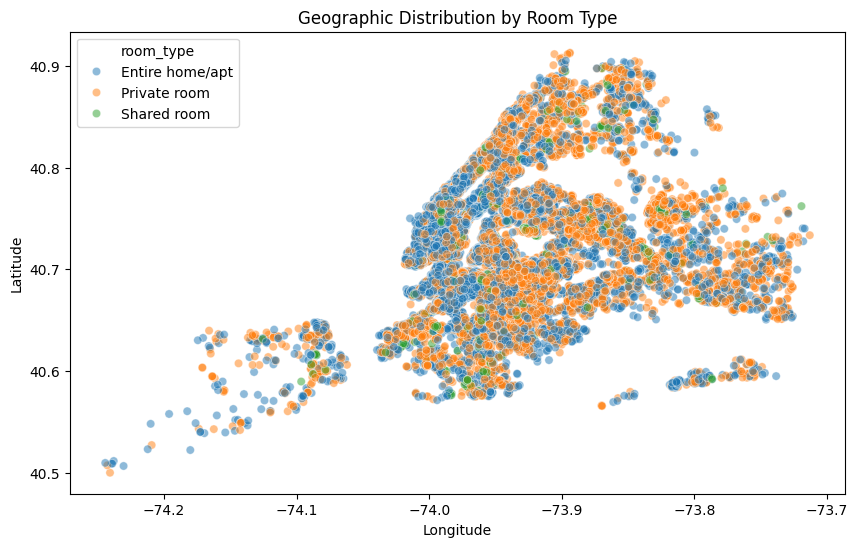

In [83]:
## 6b - Scatterplot with color points by room type
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_airbnb_clean,
    x='longitude',
    y='latitude',
    hue='room_type',
    alpha=0.5
)

plt.title("Geographic Distribution by Room Type")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 6c - Identify areas with highest listing density

The highest density for listings is in Manhattan and parts of Brooklyn (closet to Manhattan, furtherest from Long Island). Listings in these areas are much more highly concentrated as compared to other boroughs. Queens shows medium density while the Bronx and Staten Island have sparse density. This suggests that Airbnb activity is concentrated in areas of New York City that are urban and close to many of the city's well-known attractions.

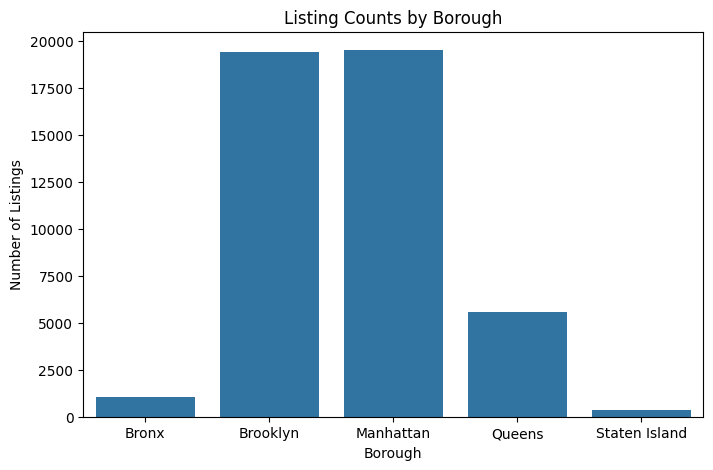

In [84]:
## 6d - Compare listing counts by borough
borough_counts = df_airbnb_clean['neighbourhood_group'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=borough_counts.index, y=borough_counts.values)
plt.title("Listing Counts by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.savefig(IMAGES_DIR / "airbnb_listing_counts_by_borough.png", dpi=300, bbox_inches="tight")
plt.show()

Manhattan and Brooklyn have the highest number of listings. The number of listings in those two boroughs far exceed the combined total of listings in other boroughs. Queens leads the remaining three boroughs with a moderate number of listings. The Bronx and Staten Island have the fewest listings among all NYC boroughs by far. This concentration aligns with higher demand in central locations that are close to known landmarks and usually have higher prices.

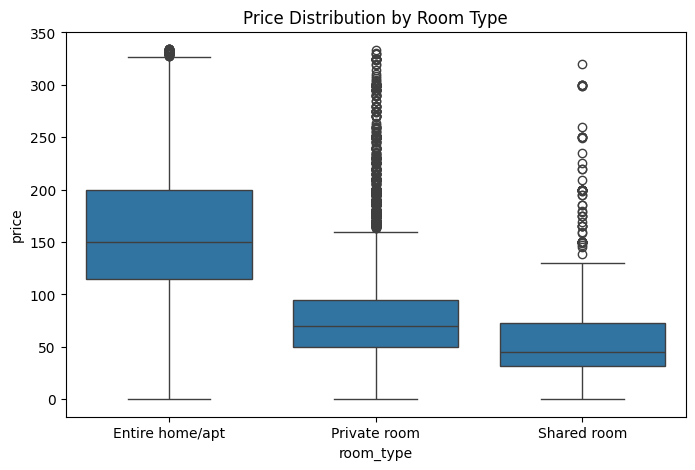

In [85]:
# 7 - Investigate factors influencing price

## 7a - Price by room type
plt.figure(figsize=(8,5))
sns.boxplot(data=df_airbnb_clean, x='room_type', y='price')
plt.title("Price Distribution by Room Type")
plt.show()

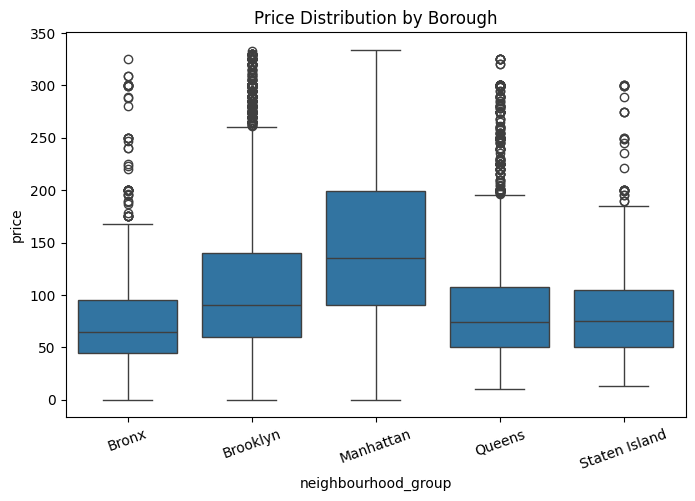

In [86]:
## 7b - Price by neighbourhood group
plt.figure(figsize=(8,5))
sns.boxplot(data=df_airbnb_clean, x='neighbourhood_group', y='price')
plt.title("Price Distribution by Borough")
plt.xticks(rotation=20)
plt.savefig(IMAGES_DIR / "airbnb_neighborhood_group_prices.png", dpi=300, bbox_inches="tight")
plt.show()

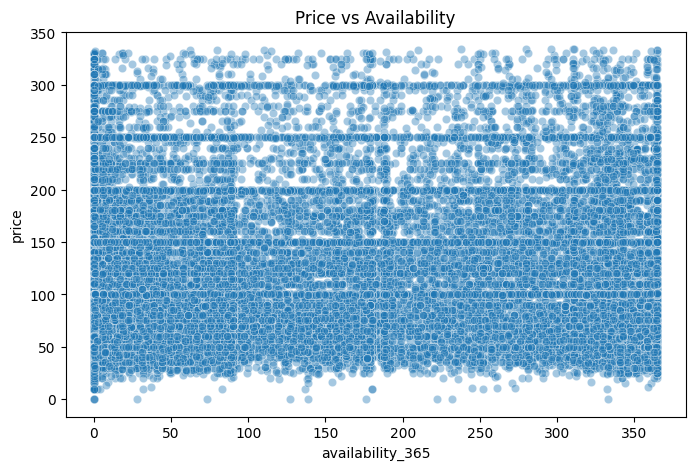

In [87]:
## 7c - Price vs availability
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_airbnb_clean, x='availability_365', y='price', alpha=0.4)
plt.title("Price vs Availability")
plt.show()

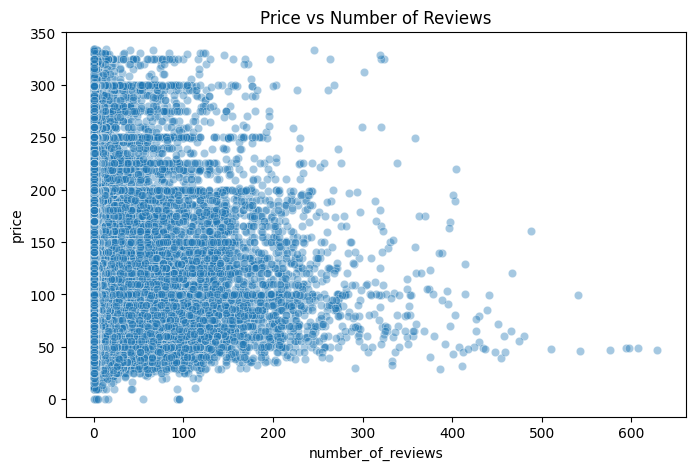

In [88]:
## 7d - Price vs number of reviews
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_airbnb_clean, x='number_of_reviews', y='price', alpha=0.4)
plt.title("Price vs Number of Reviews")
plt.show()

## 7e - Interpret findings
Prices vary widely by room type. Entire homes are typically priced at higher prices than private or shared rooms. The borough in which the listing is located also plays a major role. Listings in Manhattan, on balance, have higher prices compared to other areas in NYC. Availability and number of reviews data shows a weak relationship with price. This suggests that location and room type are strong drivers of listing price.

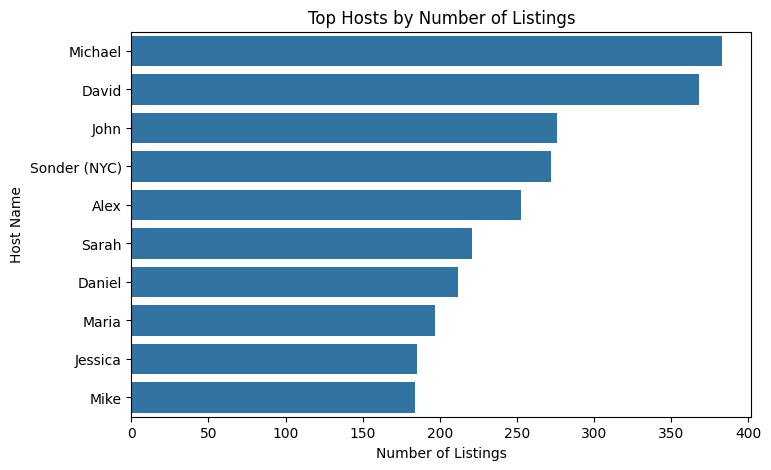

In [89]:
## 8a - Top hosts by number of listings
top_hosts = df_airbnb_clean['host_name'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_hosts.values, y=top_hosts.index)
plt.title("Top Hosts by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Host Name")
plt.show()

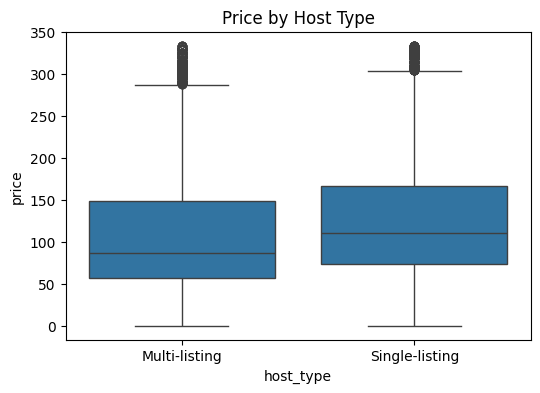

In [90]:
## 8b - Single vs multi-listing hosts
host_counts = df_airbnb_clean['host_id'].value_counts()

df_airbnb_clean['host_type'] = df_airbnb_clean['host_id'].apply(
    lambda x: 'Multi-listing' if host_counts[x] > 1 else 'Single-listing'
)

plt.figure(figsize=(6,4))
sns.boxplot(data=df_airbnb_clean, x='host_type', y='price')
plt.title("Price by Host Type")
plt.show()

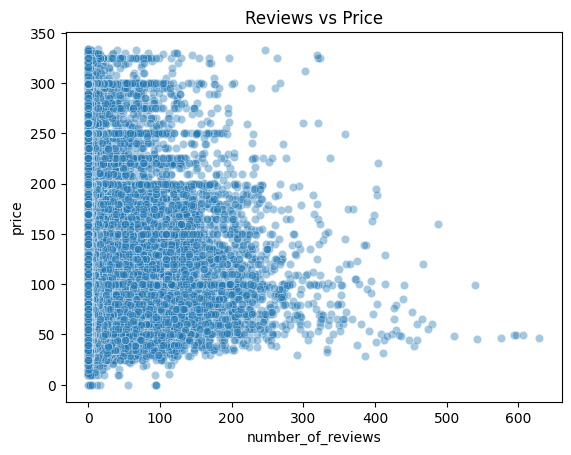

In [91]:
## 8c - Reviews vs price
sns.scatterplot(data=df_airbnb_clean, x='number_of_reviews', y='price', alpha=0.4)
plt.title("Reviews vs Price")
plt.show()

## 8d - Provide insights
A relatively small number of Airbnb hosts manage a disproportionately large number of listings. This suggests that professional or "power" hosts are present in the market.Hosts managing multiple listings usually have slightly different pricing patterns when contrasted with hosts managing a single listing. The relationship between reviews and price appears weak, which suggests that popularity does not strongly determine pricing.

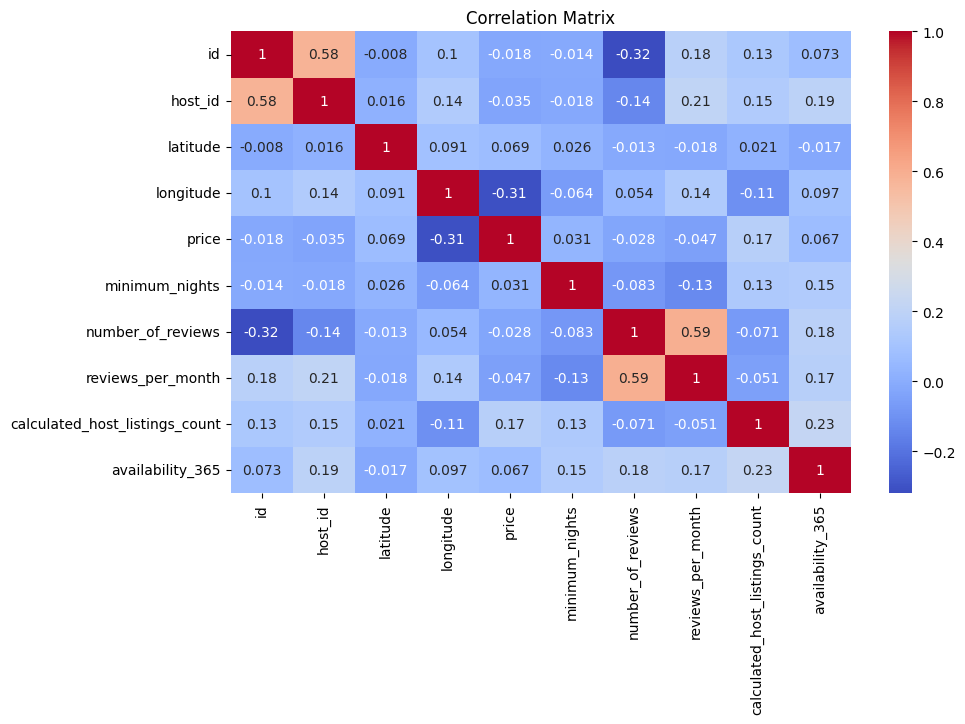

In [92]:
## 9a - Correlation matrix
corr = df_airbnb_clean.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig(IMAGES_DIR / "airbnb_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 9b - Variables most associated with price

*   There is a negative correlation with price and longitude (-0.31). Listings further west, i.e. in Manhattan, are typically more expensive than listings in other boroughs.

*   There is a weak positive relationship with price, calculated_host_listings_count (0.17), and availability_365 (0.07).
- There is a very weak relationship with price, minimum_nights, and number_of_reviews.

*   Location, specifically longitude, seems to have the strongest relationship with price. The other variables show relatively weak correlations.

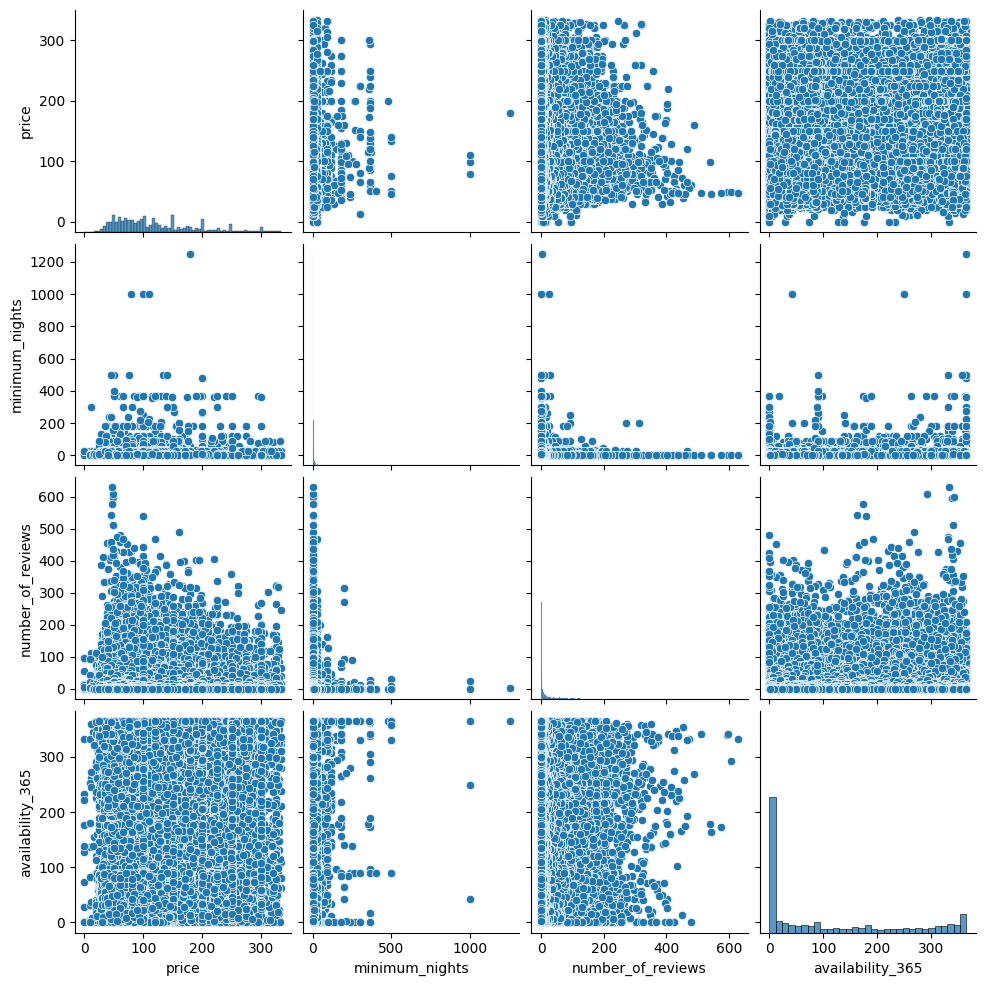

In [93]:
## 9c - Pairplot
sns.pairplot(df_airbnb_clean[['price', 'minimum_nights', 'number_of_reviews', 'availability_365']])